In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

import os
os.chdir(os.path.expanduser('~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg'))
ROOT = Path.cwd()

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [4]:
%load_ext rpy2.ipython

ModuleNotFoundError: No module named 'rpy2'

In [5]:
selected_sample = 'n16'
results_file = selected_sample + '.h5ad'  # the file that will store the analysis results
results_file

'n16.h5ad'

# Read sample metadata

In [ ]:
# read sample annotations from csv in "~/Projects/gbm-rcas/Metadata
# the first row of the csv file should be the column names
sample_annot = pd.read_csv('metadata/00-sample-metadata-raw-s16.csv', index_col=0)
sample_annot

,cellranger_file,sample_id,mouse_id,sex,sample_type,disease_state,project_id,mouse_exp_id
cellranger_id,,,,,,,,
F330260,F330260_sample_filtered_feature_bc_matrix.h5,BRAIN_01,BRAIN_01,Female,Healthy,Healthy,2023_069_1,F330260
F719_1,F719_1_sample_filtered_feature_bc_matrix.h5,BRAIN_04a,BRAIN_04,Female,Healthy,Healthy,2023_141_3,F719
F719_2,F719_2_sample_filtered_feature_bc_matrix.h5,BRAIN_04b,BRAIN_04,Female,Healthy,Healthy,2023_141_3,F719
M273,M273_sample_filtered_feature_bc_matrix.h5,BRAIN_05,BRAIN_05,Male,Healthy,Healthy,2023_141_3,M273
M275,M275_sample_filtered_feature_bc_matrix.h5,BRAIN_06,BRAIN_06,Male,Healthy,Healthy,2023_141_3,M275
F402_r2,F402_r2_sample_filtered_feature_bc_matrix.h5,TP_01b,TP_01,Female,Primary,Tumor,2023_069_2,F402
M446,M446_sample_filtered_feature_bc_matrix.h5,TP_04,TP_04,Male,Primary,Tumor,2023_141_1,M446
F442,F442_sample_filtered_feature_bc_matrix.h5,TP_05,TP_05,Female,Primary,Tumor,2023_141_1,F442
F486,F486_sample_filtered_feature_bc_matrix.h5,TP_06,TP_06,Female,Primary,Tumor,2023_141_1,F486


# Read the raw data
Get `AnnData` object in python (by filterings on cell barcodes from csv file)

In [ ]:

raw_h5_file = './data/processed/anndata/00-flex-n16-raw.h5ad'
adata = sc.read(raw_h5_file)
# adata.write(raw_h5_file)


normalizing counts per cell
    finished (0:00:00)


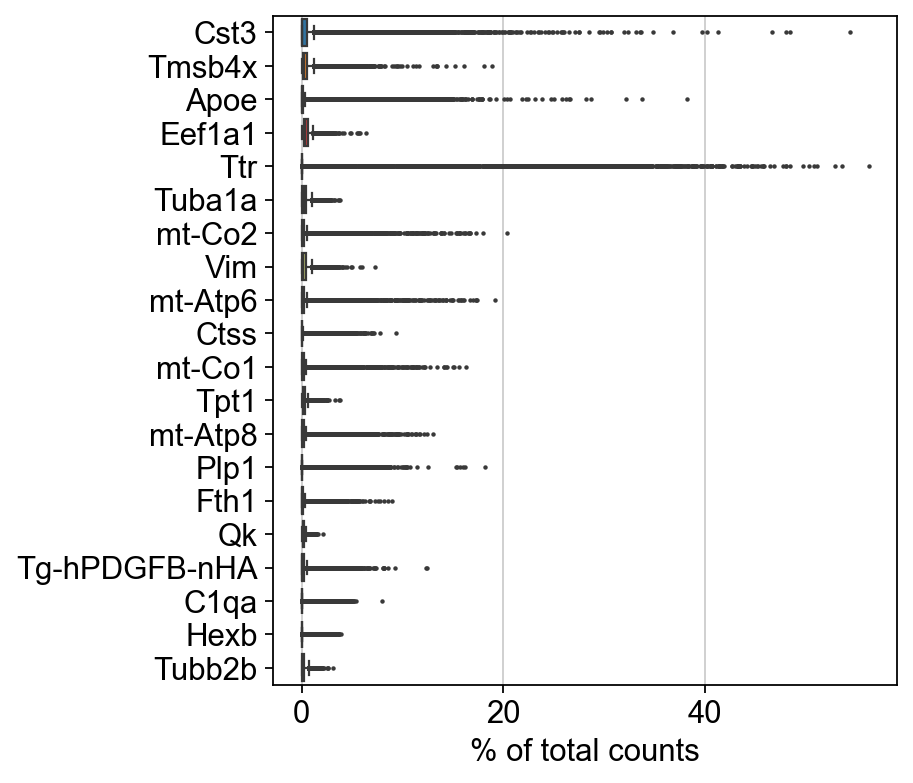

In [8]:
sc.pl.highest_expr_genes(adata, n_top=20, )

## Dropout rate
Yes, in single-cell RNA sequencing (scRNA-seq) data analysis, it's common to quantify the degree of zero-inflation or sparsity in the data. One common measure is the "dropout rate", which is the proportion of zero counts in the data matrix. 

Here's a simple way to calculate the dropout rate in Python, assuming `data` is a 2D numpy array or similar where rows are cells and columns are genes:

This will give you a value between 0 and 1, where 0 means no zero counts (no dropouts) and 1 means all counts are zero (all dropouts). 

Remember, high dropout rates are a common characteristic of scRNA-seq data due to technical limitations and biological variability.




In [9]:
import numpy as np

def calculate_dropout_rate(data):
    total_elements = np.prod(data.shape)
    zero_elements = np.sum(data == 0)
    dropout_rate = zero_elements / total_elements
    return dropout_rate

dropout_rate = calculate_dropout_rate(adata.X)
print(f"Dropout rate: {dropout_rate}")

/var/folders/1r/3rf4xlj152j5n2bfyjq1v58c0000gn/T/ipykernel_94305/2409461474.py:9: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  dropout_rate = calculate_dropout_rate(adata.X)


Dropout rate: 0.756205546152561


## Get basic QC - calculate_qc_metrics

In [10]:
# compute QC metrics. 
# First get the mitochondrial genes, starting with `MT-`
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt' 
# print a table with how many genes are mitochondrial, i.e. `adata.var['mt']==True`
print(adata.var['mt'].value_counts())

mt
False    19060
True        13
Name: count, dtype: int64


In [11]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

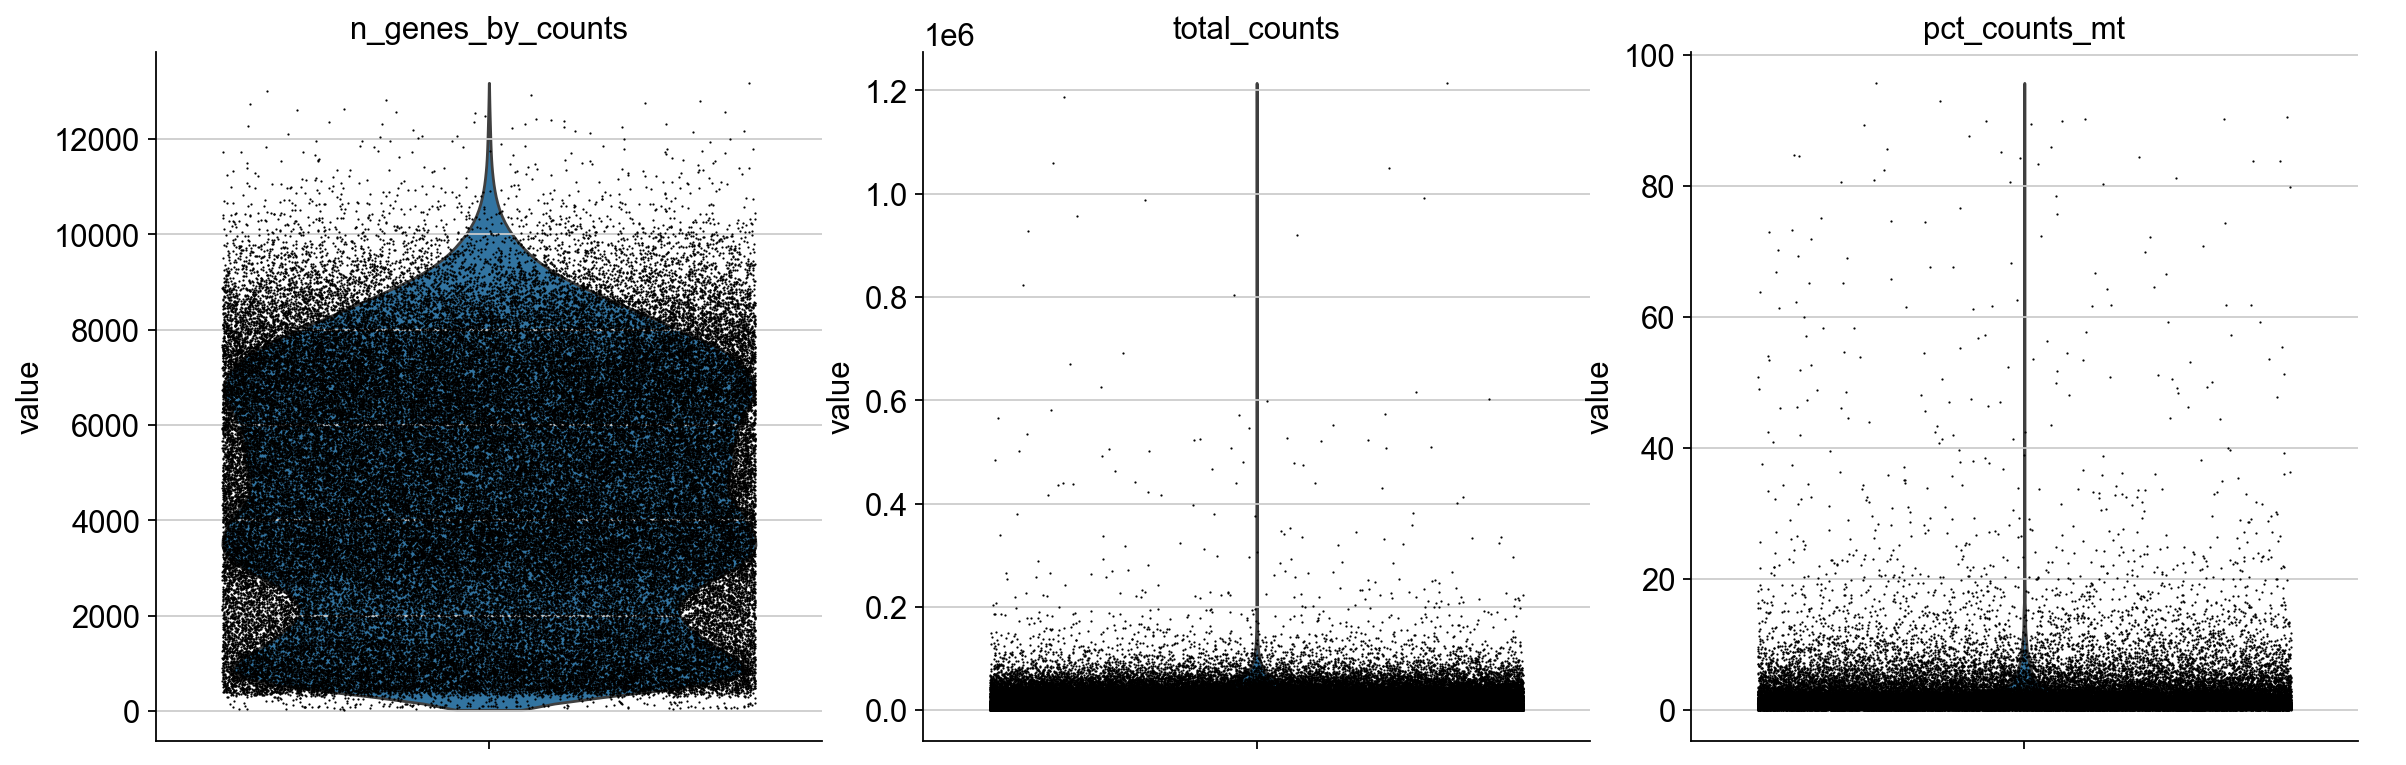

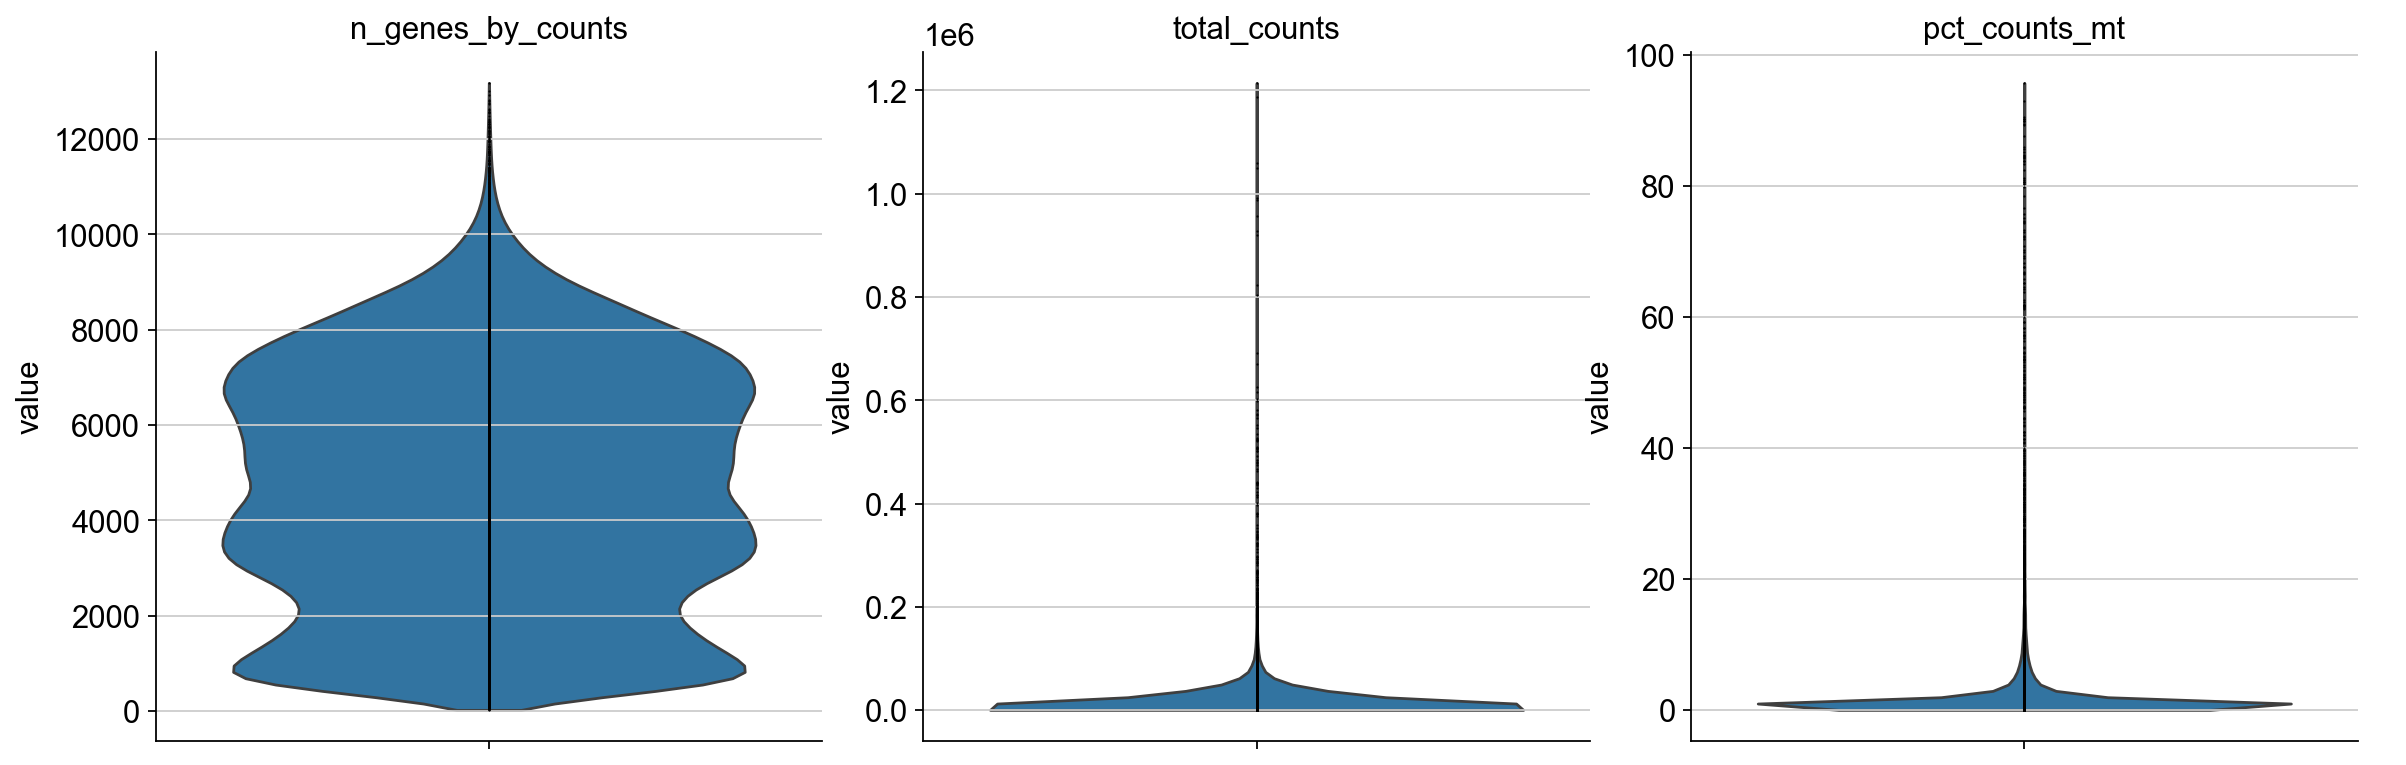

In [12]:
sc.pl.violin(
    adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, multi_panel=True)

sc.pl.violin(
    adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0, multi_panel=True)

In [13]:
import numpy as np
print("Minimum and maximum values of QC metrics:")
print("Total Counts - Min:", adata.obs['total_counts'].min(), "Max:", adata.obs['total_counts'].max())
print("Number of Genes by Counts - Min:", adata.obs['n_genes_by_counts'].min(), "Max:", adata.obs['n_genes_by_counts'].max())
print("Percentage of Counts in Mitochondrial Genes - Min:", adata.obs['pct_counts_mt'].min(), "Max:", adata.obs['pct_counts_mt'].max())


# Calculate the 5th and 95th percentiles for 'n_genes_by_counts'
n_genes_by_counts_5th = np.percentile(adata.obs['n_genes_by_counts'], 5)
n_genes_by_counts_95th = np.percentile(adata.obs['n_genes_by_counts'], 95)

# Calculate the 5th and 95th percentiles for 'total_counts'
total_counts_5th = np.percentile(adata.obs['total_counts'], 5)
total_counts_95th = np.percentile(adata.obs['total_counts'], 95)

print(f"5th percentile of 'n_genes_by_counts': {n_genes_by_counts_5th}")
print(f"95th percentile of 'n_genes_by_counts': {n_genes_by_counts_95th}")
print(f"5th percentile of 'total_counts': {total_counts_5th}")
print(f"95th percentile of 'total_counts': {total_counts_95th}")

# Do same but for 10 and 90 percentiles
n_genes_by_counts_10th = np.percentile(adata.obs['n_genes_by_counts'], 10)
n_genes_by_counts_90th = np.percentile(adata.obs['n_genes_by_counts'], 90)

total_counts_10th = np.percentile(adata.obs['total_counts'], 10)
total_counts_90th = np.percentile(adata.obs['total_counts'], 90)

print(f"10th percentile of 'n_genes_by_counts': {n_genes_by_counts_10th}")
print(f"90th percentile of 'n_genes_by_counts': {n_genes_by_counts_90th}")
print(f"10th percentile of 'total_counts': {total_counts_10th}")
print(f"90th percentile of 'total_counts': {total_counts_90th}")


Minimum and maximum values of QC metrics:
Total Counts - Min: 493.0 Max: 1214358.0
Number of Genes by Counts - Min: 23 Max: 13180
Percentage of Counts in Mitochondrial Genes - Min: 0.0 Max: 95.721924
5th percentile of 'n_genes_by_counts': 718.0
95th percentile of 'n_genes_by_counts': 8591.0
5th percentile of 'total_counts': 1091.0
95th percentile of 'total_counts': 57451.5625
10th percentile of 'n_genes_by_counts': 1103.0
90th percentile of 'n_genes_by_counts': 7951.400000000009
10th percentile of 'total_counts': 1792.0
90th percentile of 'total_counts': 43630.1953125


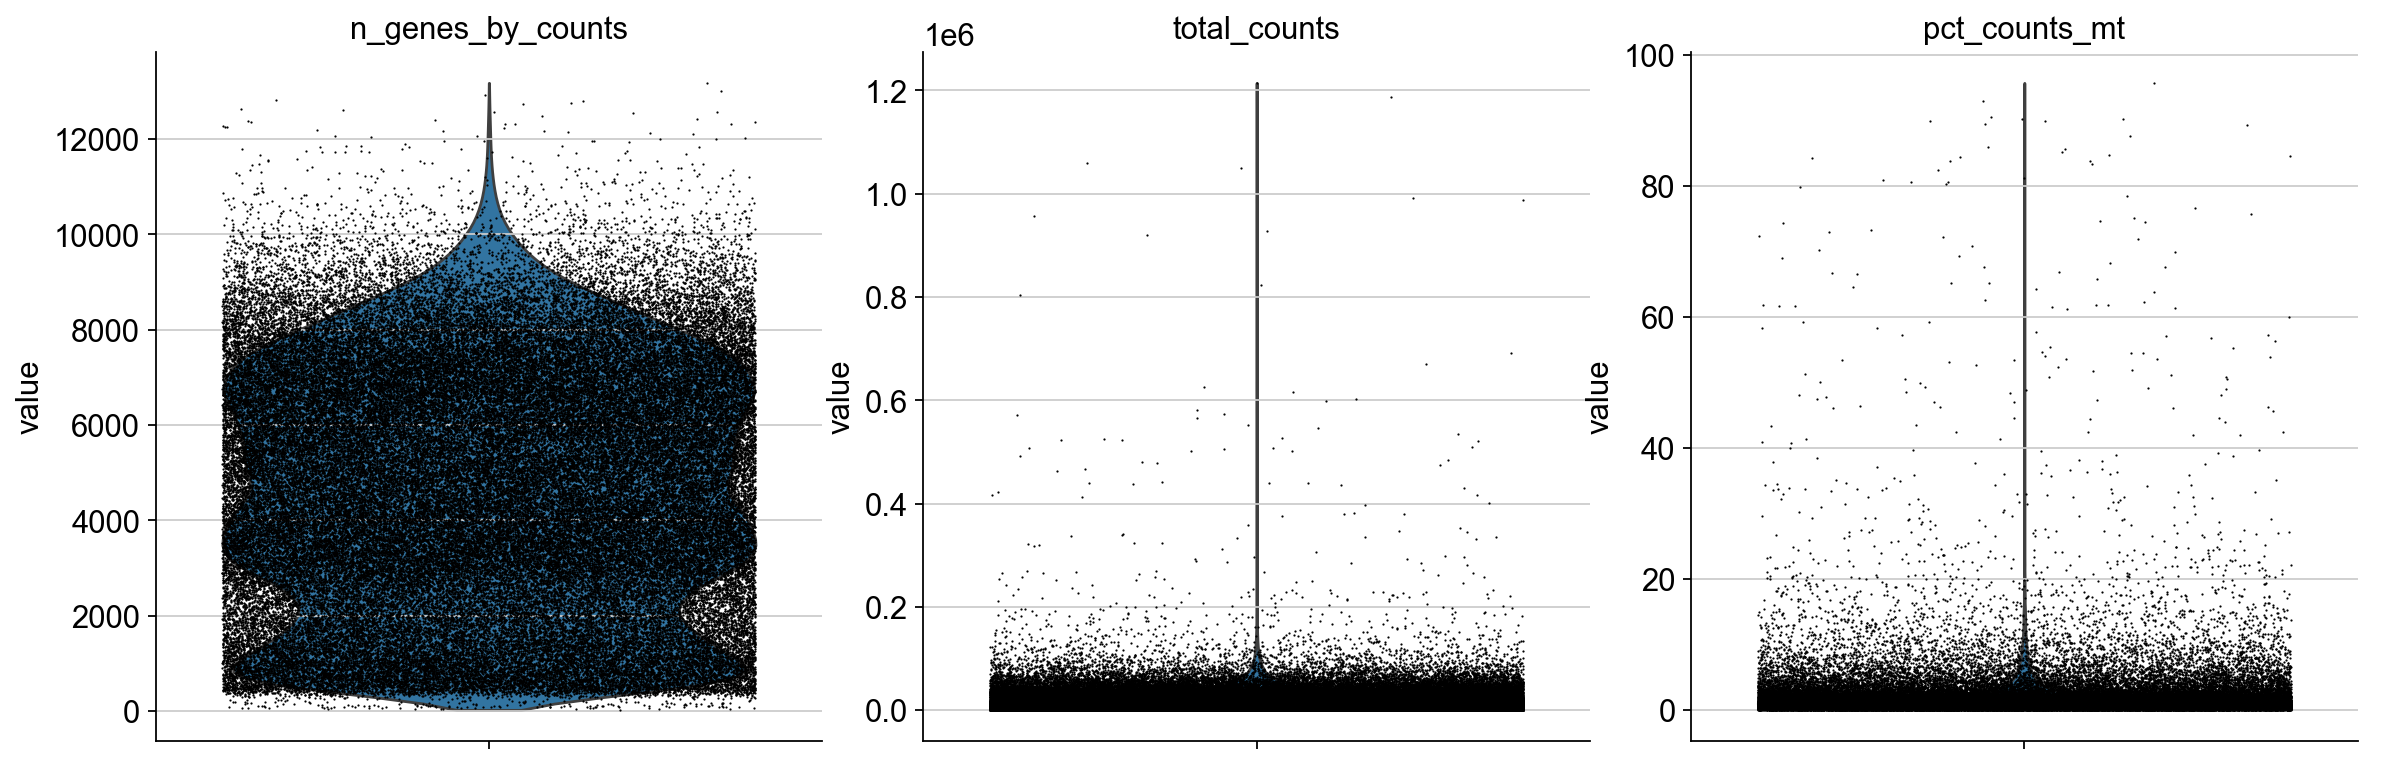

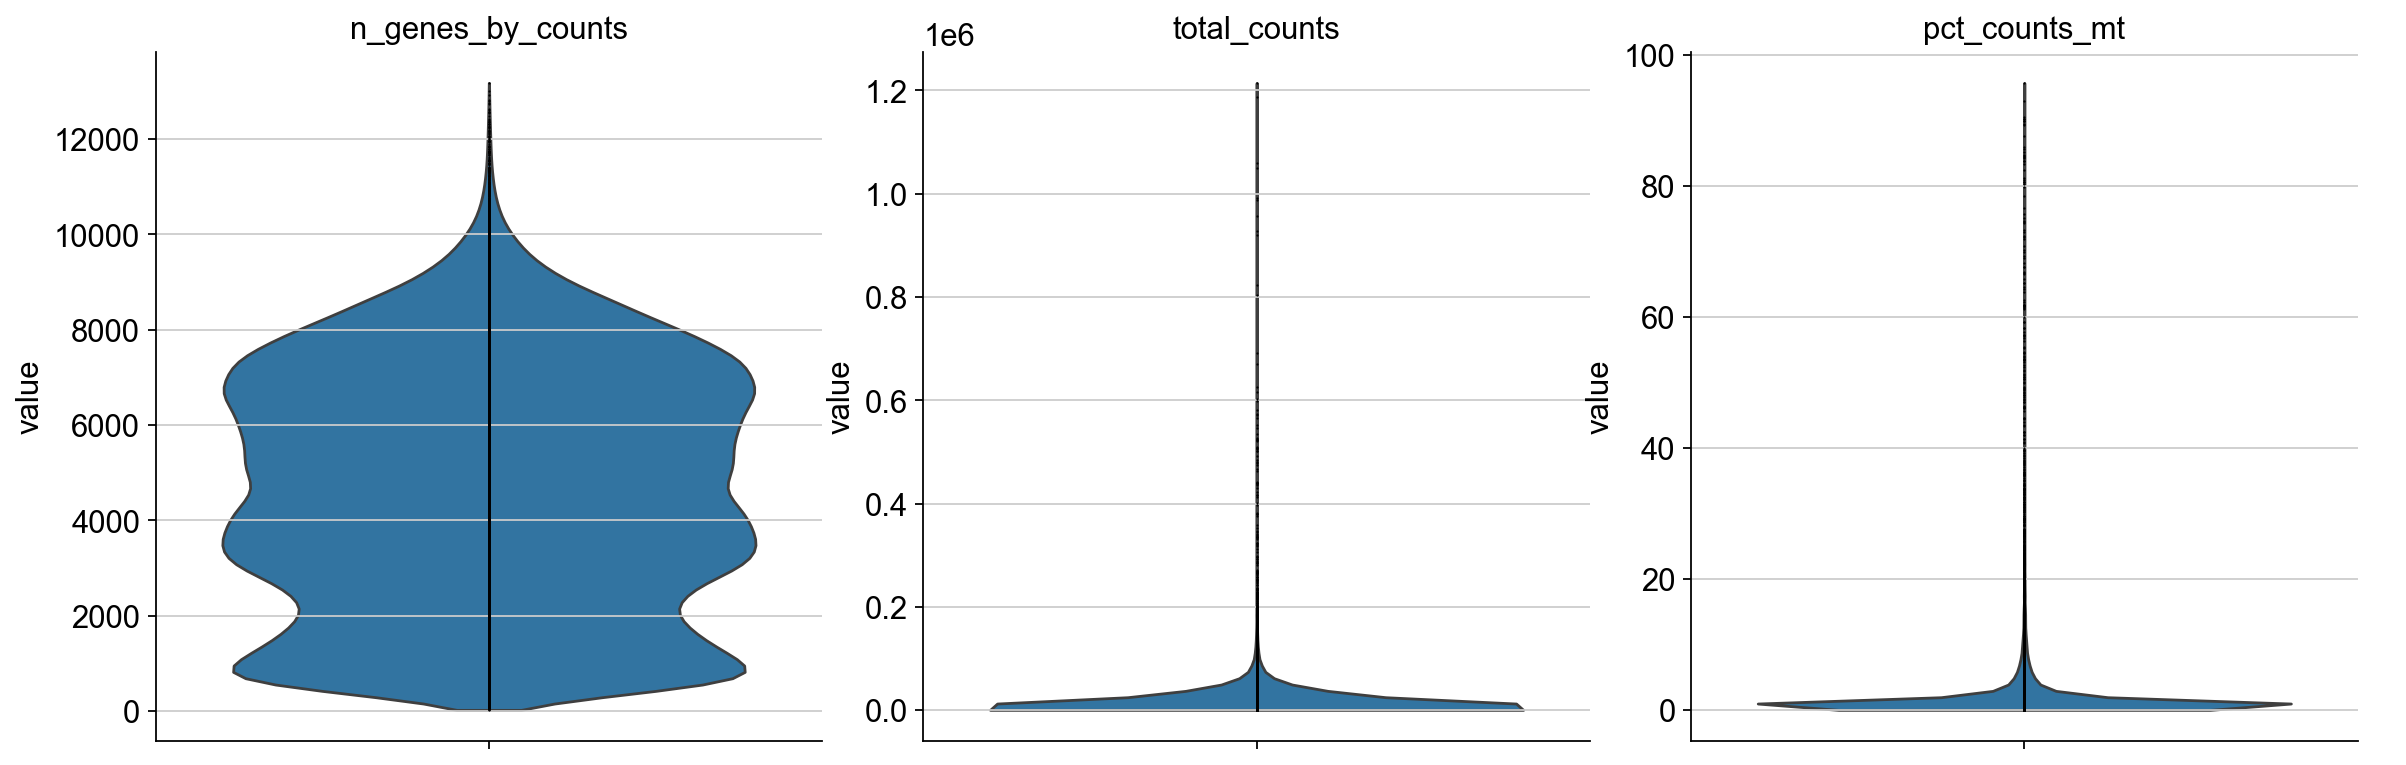

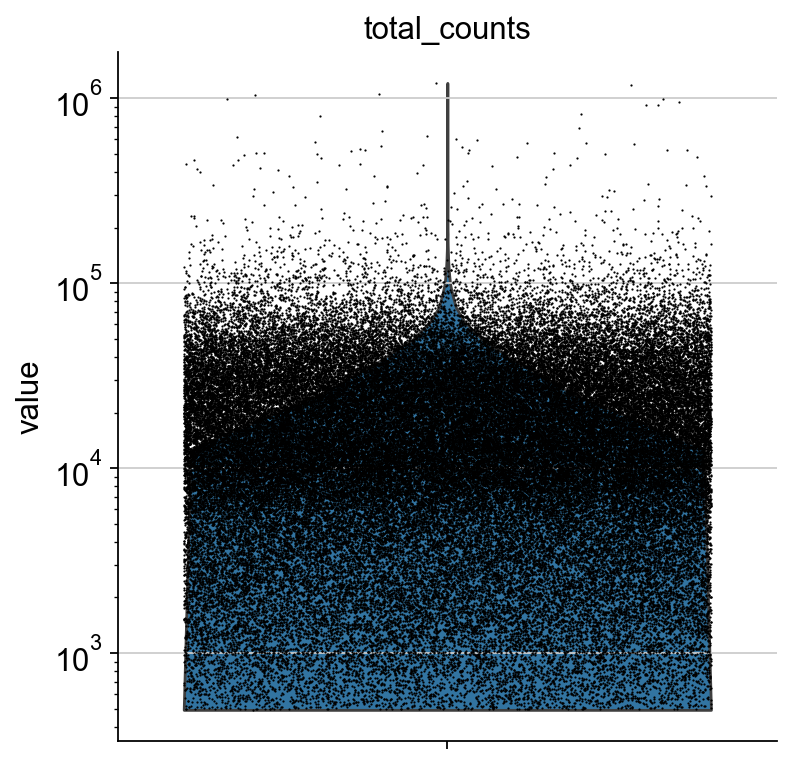

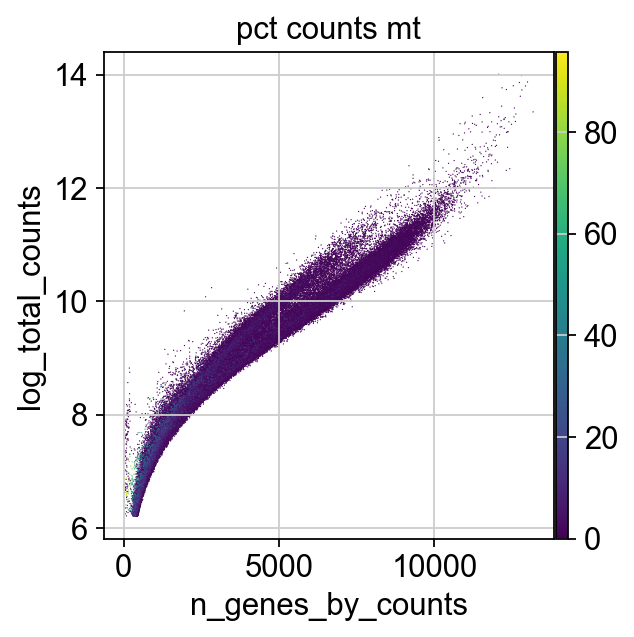

In [14]:
sc.pl.violin(
    adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, multi_panel=True)

sc.pl.violin(
    adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0, multi_panel=True)


# Plot total counts but logged. do not plot individual values with dot
sc.pl.violin(
    adata, ['total_counts'],
    jitter=0.4, multi_panel=True, log=True, stripplot=True)

# Apply the logarithm to the 'n_genes_by_counts' column
adata.obs['log_total_counts'] = np.log1p(adata.obs['total_counts'])

# Plot the data
sc.pl.scatter(
    adata, x='n_genes_by_counts', 
    y='log_total_counts', color='pct_counts_mt')

In [15]:
# print max and min values of the total counts
print(f"Min total counts: {adata.obs['total_counts'].min()}")
print(f"Max total counts: {adata.obs['total_counts'].max()}")   


Min total counts: 493.0
Max total counts: 1214358.0


## Add pyminer-norm code - Downsampling
"However, I'd strongly advise also filtering based on total UMI count before! With downsampling you've got to chuck everything that doesn't have enough counts. In their original analysis, there was a cell with 556 UMI, while in the same dataset another cell had 8875 (over an order of magnitude more!). This dramatic range is what we're accounting for with downsampling. So - instead of the above, I'd recommend swapping:

[14]: sc.pp.normalize_total(adata, target_sum=1e4)
for 
[14]: adata = adata[adata.obs.total_counts >= 1750, :]
[15]: adata.X = downsample_mat(adata.X.transpose()).transpose()"

Skip pre-filtering. Build a number of data sets with different downsample-count cutoffs.
Use 2.5k, 5k, 10k, 25k, 50k, and 100k 

## Run `pyminer-norm.downsample`

In [16]:
# calculate the dropout rate for original data
import numpy as np

def calculate_dropout_rate(data):
    total_elements = np.prod(data.shape)
    zero_elements = np.sum(data == 0)
    dropout_rate = zero_elements / total_elements
    return dropout_rate

dropout_rate = calculate_dropout_rate(adata.X)
print(f"Dropout rate: {dropout_rate}")

/var/folders/1r/3rf4xlj152j5n2bfyjq1v58c0000gn/T/ipykernel_94305/1369367006.py:10: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  dropout_rate = calculate_dropout_rate(adata.X)


Dropout rate: 0.756205546152561


In [19]:
import ray

# Make sure no Ray instance is running
if ray.is_initialized():
    ray.shutdown()

In [20]:
from pyminer_norm.downsample import downsample_mat
import ray

count_cutoffs = [2500, 5000, 10000, 25000, 50000, 57451, 100000]

for count_cutoff in count_cutoffs:
    print(f"Downsampling to count_cutoff: {count_cutoff}")

    # Ensure Ray is not already running before pyminer_norm tries to init it
    if ray.is_initialized():
        ray.shutdown()

    adata_ds = adata.copy()
    adata_ds.X = downsample_mat(
        adata_ds.X.transpose(), 
        target_count=count_cutoff
    ).transpose()

    dropout_rate = calculate_dropout_rate(adata_ds.X)
    print(f"Dropout rate: {dropout_rate} for count_cutoff: {count_cutoff}")

    # ---- your QC + plotting + saving code unchanged below ----
    sc.pp.calculate_qc_metrics(
        adata_ds, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
    )

    sc.pl.violin(
        adata_ds, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
        jitter=0.4, multi_panel=True
    )

    sc.pl.violin(
        adata_ds, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
        jitter=0, multi_panel=True
    )

    sc.pl.violin(
        adata_ds, ['total_counts'],
        jitter=0.4, multi_panel=True, log=True, stripplot=False
    )

    adata_ds.obs['log_total_counts'] = np.log1p(adata_ds.obs['total_counts'])

    sc.pl.scatter(
        adata_ds, x='n_genes_by_counts',
        y='log_total_counts', color='pct_counts_mt'
    )

    print("Minimum and maximum values of QC metrics:")
    print("Total Counts - Min:", adata_ds.obs['total_counts'].min(),
          "Max:", adata_ds.obs['total_counts'].max())
    print("Number of Genes by Counts - Min:", adata_ds.obs['n_genes_by_counts'].min(),
          "Max:", adata_ds.obs['n_genes_by_counts'].max())
    print("Percentage of Counts in Mitochondrial Genes - Min:",
          adata_ds.obs['pct_counts_mt'].min(),
          "Max:", adata_ds.obs['pct_counts_mt'].max())

    # percentiles ...
    # (keep the rest of your percentile + rename + save code the same)

Downsampling to count_cutoff: 2500
beginning downsampling
getting transcript vectors


2025-12-12 07:45:30,782	INFO worker.py:2023 -- Started a local Ray instance.


OutOfDiskError: Local disk is full
The object cannot be created because the local object store is full and the local disk's utilization is over capacity (95% by default).Tip: Use `df` on this node to check disk usage and `ray memory` to check object store memory usage.

(raylet) [2025-12-12 07:45:40,749 E 17167 19142680] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-12-12_07-45-28_924631_94305 is over 95% full, available space: 86.843 GB; capacity: 1858.19 GB. Object creation will fail if spilling is required.
(raylet) [2025-12-12 07:45:50,840 E 17167 19142680] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-12-12_07-45-28_924631_94305 is over 95% full, available space: 86.841 GB; capacity: 1858.19 GB. Object creation will fail if spilling is required.
(pid=gcs_server) [2025-12-12 07:45:59,284 E 17163 19142526] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2025-12-12 07:46:00,797 E 17167 19142658] (raylet) main.cc:979: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent 